[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Clases/Clase20260514.ipynb)

In [2]:
!pip install pymcel celluloid -q

In [28]:
import numpy as np
import pymcel as pc
import matplotlib.pyplot as plt
import sympy as sp
from celluloid import Camera
from IPython.display import HTML, display
from scipy.integrate import solve_ivp

In [15]:
n, t = sp.symbols(" n, t")
xp = sp.Function("x'")(t)
yp = sp.Function("y'")(t)
x = xp * sp.cos(n*t) - yp * sp.sin(n*t)
y = xp * sp.sin(n*t) + yp * sp.cos(n*t)

dx = sp.diff(x, t)
dy = sp.diff(y, t)

In [20]:
sp.simplify(dx**2 + dy**2)

n**2*x'(t)**2 + n**2*y'(t)**2 + 2*n*x'(t)*Derivative(y'(t), t) - 2*n*y'(t)*Derivative(x'(t), t) + Derivative(x'(t), t)**2 + Derivative(y'(t), t)**2

# Ecuaciones del CR3BP

In [26]:
def edm_crtbp(t, Ys, alpha):
    x, y, z, vx, vy, vz = Ys

    # Variables auxiliares
    x1 = - alpha
    x2 = 1 - alpha
    r1 = np.sqrt((x-x1)**2+y**2+z**2)
    r2 = np.sqrt((x-x2)**2+y**2+z**2)

    # Ecuaciones
    dx_dt = vx
    dy_dt = vy
    dz_dt = vz

    dvx_dt = +2*vy + x - (1 - alpha)/ r1**3 * (x - x1) - alpha/r2**3 * (x - x2)
    dvy_dt = -2*vx + y - (1 - alpha)/ r1**3 * y - alpha/r2**3 * y
    dvz_dt =           - (1 - alpha)/ r1**3 * z - alpha/r2**3 * z

    return [dx_dt, dy_dt, dz_dt, dvx_dt, dvy_dt, dvz_dt]

In [27]:
edm_crtbp(1,[1,2,3,4,5,6],1)

[4,
 5,
 6,
 np.float64(10.98090991129197),
 np.float64(-6.038180177416061),
 np.float64(-0.05727026612409094)]

In [58]:
alpha = 0.3
ts = np.linspace(0, 25, 1000)
Ys = [1,0,0,-0.05,0.6,0]
sol = solve_ivp(edm_crtbp,
                [ts[0], ts[-1]],
                Ys,
                args=(alpha,),
                t_eval=ts,
                method = "Radau")

In [59]:
xs = sol.y[0]
ys = sol.y[1]
zs = sol.y[2]
vxs = sol.y[3]
vys = sol.y[4]
vzs = sol.y[5]

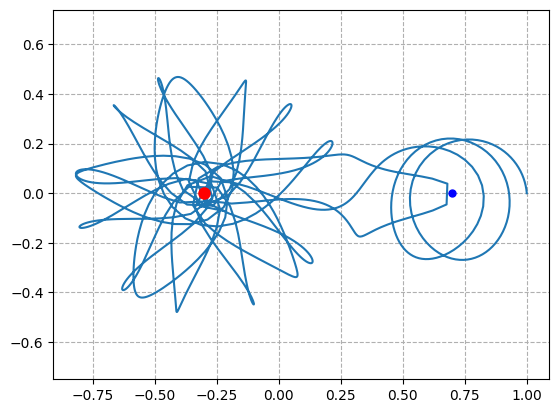

In [60]:
plt.plot(xs, ys)
plt.plot(-alpha, 0, "ro", ms=8)
plt.plot(1-alpha, 0, "bo", ms=5)
plt.axis("equal")
plt.grid(ls="--")